# Multi-Output Gaussian Process: Training and Evaluation

This notebook implements the training and evaluation pipeline for the Multi-Output Gaussian Process (MOGP) model using the processed features extracted in the previous step.

**Objectives:**
1.  **Load Processed Data:** Import the extracted topological features and targets.
2.  **Define Model:** Initialize the Variational GP with LMC.
3.  **Train:** Optimize the model using the ELBO loss function.
4.  **Evaluate:** Assess performance on classification (Overlap) and regression (OSNR) tasks.

## 1. Setup and Imports

In [15]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, roc_auc_score, roc_curve

# Import project modules
# Ensure the project root is in the python path if running from a subdirectory
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.utils.data_loader import load_dataset
from src.models.mixed_gp import MixedGPModel
from torch.utils.data import TensorDataset, DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load Data

We load the pre-processed features (`X_features.npy`) and targets (`Y_targets.npy`).

*   **Task 0 (Classification):** Channel Overlap (Binary). Derived from Spacing <= 35.2 GHz.
*   **Task 1 (Regression):** OSNR (Continuous).

In [6]:
print("Loading dataset...")
train_x, train_y, test_x, test_y, scaler_x, scaler_y = load_dataset(data_path="processed_data")

print(f"Train X shape: {train_x.shape}")
print(f"Train Y shape: {train_y.shape}")
print(f"Test X shape:  {test_x.shape}")
print(f"Test Y shape:  {test_y.shape}")

# Move to device
train_x = train_x.to(device)
train_y = train_y.to(device)
test_x = test_x.to(device)
test_y = test_y.to(device)

Loading dataset...
Loading data from processed_data...
Loaded X: (5006, 20), Y: (5006, 2)
Train X shape: torch.Size([4004, 20])
Train Y shape: torch.Size([4004, 2])
Test X shape:  torch.Size([1002, 20])
Test Y shape:  torch.Size([1002, 2])


## 3. Model Definition

**Note on Methodology:**
Although our dataset is small (~5k samples), we **must** use Variational Inference (Approximate GP) because we have a **Mixed Likelihood**.
Exact GP inference is only possible when *all* likelihoods are Gaussian:
*   **Task 0 (Overlap):** Bernoulli Likelihood (Non-Gaussian).
*   **Task 1 (OSNR):** Gaussian Likelihood.


For training performance optimization we use inducing points to reduce the complexity of the training procedure while maintaining a decent representation
of the modelling.

We initialize the `MixedGPModel` which uses:
*   **Variational GP:** With $M=1200$ inducing points (roughly 25%).
*   **Linear Model of Coregionalization (LMC):** To capture correlations between Overlap and OSNR.
*   **LikelihoodList:** To handle mixed binary and continuous outputs.

In [7]:
# Hyperparameters
num_latents = 3

# Inducing Points
# Optimization: Use M=1200 inducing points (Sparse Approximation).
num_inducing = 1200
if train_x.size(0) < num_inducing:
    num_inducing = train_x.size(0)

inducing_idx = torch.randperm(train_x.size(0))[:num_inducing]
inducing_points = train_x[inducing_idx].clone()

print(f"Using {num_inducing} inducing points (Sparse Approximation)")

# Model
model = MixedGPModel(inducing_points, num_latents=num_latents, num_tasks=2).to(device)

# Likelihoods
# Task 0: Overlap -> Bernoulli
# Task 1: OSNR -> Gaussian
likelihood = gpytorch.likelihoods.LikelihoodList(
    gpytorch.likelihoods.BernoulliLikelihood(),
    gpytorch.likelihoods.GaussianLikelihood()
).to(device)

Using 1200 inducing points (Sparse Approximation)


## 4. Training Loop

We optimize the Evidence Lower Bound (ELBO).

In [ ]:
# Training Config
epochs = 50
batch_size = 1024  # Increased for speed
lr = 0.01

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=lr)

train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model.train()
likelihood.train()

loss_history = []

print("Starting training...")
pbar = tqdm(range(epochs))

for epoch in pbar:
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        output = model(batch_x)
        
        # Separate distributions
        mean = output.mean
        var = output.variance
        dist_overlap = gpytorch.distributions.MultivariateNormal(mean[:, 0], torch.diag_embed(var[:, 0]))
        dist_osnr = gpytorch.distributions.MultivariateNormal(mean[:, 1], torch.diag_embed(var[:, 1]))
        
        # Calculate Loss (Negative ELBO)
        log_prob_overlap = likelihood.likelihoods[0].expected_log_prob(batch_y[:, 0], dist_overlap).sum()
        log_prob_osnr = likelihood.likelihoods[1].expected_log_prob(batch_y[:, 1], dist_osnr).sum()
        kl_div = model.variational_strategy.kl_divergence().sum()
        
        scale = train_x.size(0) / batch_x.size(0)
        loss = -(scale * (log_prob_overlap + log_prob_osnr) - kl_div)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    pbar.set_postfix({'loss': avg_loss})

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Training Loss (Negative ELBO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Starting training...


  0%|          | 0/50 [00:00<?, ?it/s]

## 5. Evaluation

We evaluate the model on the test set.

In [12]:
model.eval()
likelihood.eval()

test_dataset = TensorDataset(test_x, test_y)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

all_preds_osnr = []
all_probs_overlap = []
all_targets_osnr = []
all_targets_overlap = []
all_std_osnr = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        output = model(batch_x)
        mean = output.mean
        var = output.variance
        
        # Overlap Predictions (Probabilities)
        dist_overlap = gpytorch.distributions.MultivariateNormal(mean[:, 0], torch.diag_embed(var[:, 0]))
        probs_overlap = likelihood.likelihoods[0](dist_overlap).mean
        
        # OSNR Predictions (Normalized)
        pred_osnr_norm = mean[:, 1]
        var_osnr_norm = var[:, 1]
        
        all_probs_overlap.append(probs_overlap.cpu().numpy())
        all_preds_osnr.append(pred_osnr_norm.cpu().numpy())
        all_std_osnr.append(np.sqrt(var_osnr_norm.cpu().numpy()))
        
        all_targets_overlap.append(batch_y[:, 0].cpu().numpy())
        all_targets_osnr.append(batch_y[:, 1].cpu().numpy())

# Concatenate
probs_overlap = np.concatenate(all_probs_overlap)
preds_osnr_norm = np.concatenate(all_preds_osnr)
std_osnr_norm = np.concatenate(all_std_osnr)
targets_overlap = np.concatenate(all_targets_overlap)
targets_osnr_norm = np.concatenate(all_targets_osnr)

# Inverse Transform OSNR
preds_osnr = scaler_y.inverse_transform(preds_osnr_norm.reshape(-1, 1)).flatten()
targets_osnr = scaler_y.inverse_transform(targets_osnr_norm.reshape(-1, 1)).flatten()
std_osnr = std_osnr_norm * scaler_y.scale_[0]

# Binarize Overlap Predictions
preds_overlap_binary = (probs_overlap > 0.5).astype(float)

### 5.1 Classification Results (Channel Overlap)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.24      0.36       303
         1.0       0.74      0.95      0.83       699

    accuracy                           0.73      1002
   macro avg       0.70      0.59      0.59      1002
weighted avg       0.72      0.73      0.69      1002

ROC-AUC Score: 0.7366


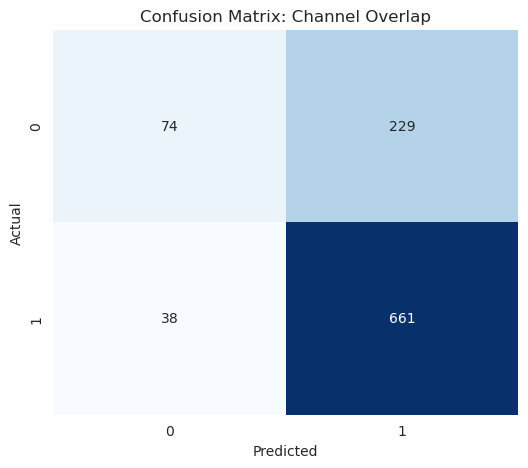

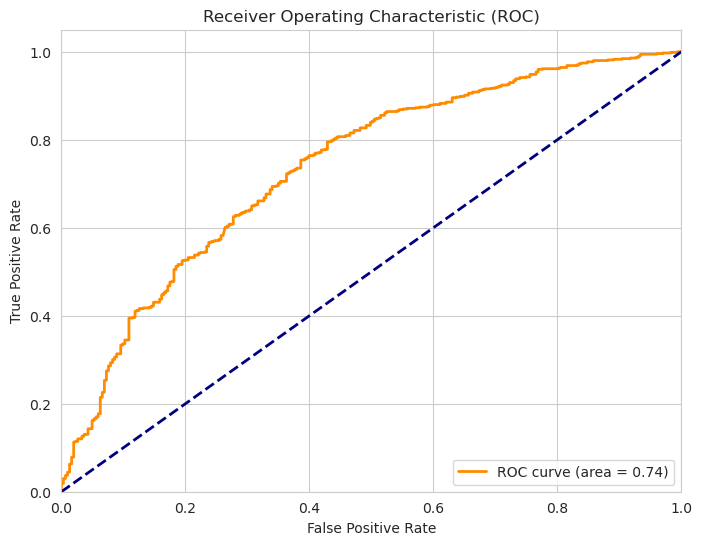

In [16]:
print("Classification Report:")
print(classification_report(targets_overlap, preds_overlap_binary))

# ROC-AUC Score
roc_auc = roc_auc_score(targets_overlap, probs_overlap)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(targets_overlap, preds_overlap_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Channel Overlap')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(targets_overlap, probs_overlap)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### 5.2 Regression Results (OSNR)

OSNR MAE:  2.4755 dB
OSNR RMSE: 3.0135 dB


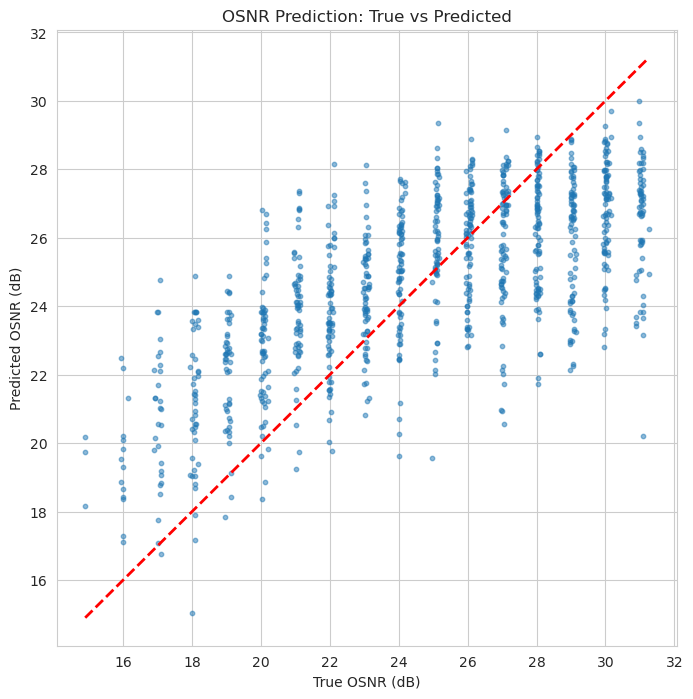

In [17]:
mae = mean_absolute_error(targets_osnr, preds_osnr)
rmse = np.sqrt(mean_squared_error(targets_osnr, preds_osnr))

print(f"OSNR MAE:  {mae:.4f} dB")
print(f"OSNR RMSE: {rmse:.4f} dB")

# Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(targets_osnr, preds_osnr, alpha=0.5, s=10)
plt.plot([min(targets_osnr), max(targets_osnr)], [min(targets_osnr), max(targets_osnr)], 'r--', lw=2)
plt.xlabel('True OSNR (dB)')
plt.ylabel('Predicted OSNR (dB)')
plt.title('OSNR Prediction: True vs Predicted')
plt.grid(True)
plt.show()